# EEG_07e — Pre-costruzione Tensori Grafo / Ipergrafo da CSV

Legge i CSV di Paolo (`data/raw_csv/training_set/PXXX_SYYY/parola_img.csv`)
e costruisce tensori PyG `Data(x, edge_index, y, subj, sess)` in `data/interim/graphs/`.

**Struttura CSV**: 61 righe × 384 colonne (canali × campioni), nessun header.

Supporta:
- Metodi connettività: **PCC**, **PLV**, **wPLI**
- K valori per k-NN
- **Pruning**: soglia edge + rimozione canali a bassa connettività
- Costruzione **ipergrafo** (per EEG_11)

In [ ]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

# Metodi connettività
METHODS = ["wpli"]           # "pcc" | "plv" | "wpli"

# K-vicini per k-NN graph
K_VALUES = [6]

# Costruisci anche ipergrafo (per EEG_11)
BUILD_HGNN = True
K_HYPER    = 6

# Schema label da applicare
CLUSTER_SCHEME = "concr4"   # "concr4" | "ward4" | "sem5" | "pos4" | "raw110"

# Forza ricostruzione anche se file già esiste
FORCE_REBUILD = True

print("Config OK")

Config OK


In [3]:
# ============================================================
# IMPORT E PATHS
# ============================================================

import os, sys, json
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import torch

torch.multiprocessing.set_sharing_strategy('file_system')  # evita OOM su /dev/shm condivisa
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.data import Data

# Trova project root
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

# Paths
CSV_ROOT   = project_root / "data" / "raw_csv" / "training_set"
GRAPHS_DIR = project_root / "data" / "interim" / "graphs"
CONFIGS    = project_root / "configs" / "label_schemes"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

N_CHANS   = 61
N_SAMPLES = 384

# Mapping parola → label_id (da label2idx.json)
with open(CONFIGS / "label2idx.json") as f:
    word2labelid = json.load(f)   # {"accendere": 0, "acqua": 1, ...}

# Schema cluster
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(CLUSTER_SCHEME, project_root / "data" / "interim")

# Lista cartelle soggetto-sessione
session_dirs = sorted(CSV_ROOT.iterdir())
print(f"Project root  : {project_root}")
print(f"CSV root      : {CSV_ROOT}")
print(f"Cartelle sess : {len(session_dirs)}")  # ~357
print(f"N_CHANS       : {N_CHANS}")
print(f"Schema        : {CLUSTER_SCHEME} ({N_CLASSES} classi)")
print(f"Esempio dir   : {session_dirs[0].name}")

Project root  : /home/daniele_u/miralis-hypergraph-imagined-speech
CSV root      : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
Cartelle sess : 357
N_CHANS       : 61
Schema        : concr4 (4 classi)
Esempio dir   : P000_S001


In [4]:
# ============================================================
# PARSING NOMI CARTELLA
# PXXX_SYYY → subj_id (int), sess_id (int)
# ============================================================

def parse_folder(folder_name: str):
    """Es. 'P003_S002' → (3, 2)"""
    parts = folder_name.split("_")
    subj = int(parts[0][1:])   # rimuove 'P'
    sess = int(parts[1][1:])   # rimuove 'S'
    return subj, sess

def load_csv_trial(csv_path: Path) -> np.ndarray:
    """Legge CSV 61×384 senza header. Restituisce array float32 (61, 384)."""
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)

# Test
test_dir = session_dirs[0]
test_csv = sorted(test_dir.iterdir())[0]
x_test   = load_csv_trial(test_csv)
subj_t, sess_t = parse_folder(test_dir.name)
word_t   = test_csv.stem.replace("_img", "")

print(f"Cartella: {test_dir.name} → subj={subj_t}, sess={sess_t}")
print(f"File    : {test_csv.name} → parola='{word_t}', label_id={word2labelid.get(word_t, '??')}")
print(f"Shape   : {x_test.shape}  (atteso: (61, 384))")
assert x_test.shape == (N_CHANS, N_SAMPLES), f"Shape attesa ({N_CHANS}, {N_SAMPLES}), trovata {x_test.shape}"
print("✅ Parsing OK")

Cartella: P000_S001 → subj=0, sess=1
File    : accendere_img.csv → parola='accendere', label_id=0
Shape   : (61, 384)  (atteso: (61, 384))
✅ Parsing OK


In [5]:
# ============================================================
# FUNZIONI DI CONNETTIVITÀ
# ============================================================

def pcc_matrix(x_np: np.ndarray) -> np.ndarray:
    """Pearson |PCC| tra canali. Shape: (N, N)"""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc


def plv_matrix(x_np: np.ndarray) -> np.ndarray:
    """Phase Locking Value via Hilbert. Shape: (N, N)"""
    from scipy.signal import hilbert
    N = x_np.shape[0]
    phases = np.angle(hilbert(x_np, axis=1))
    plv = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            diff = phases[i] - phases[j]
            plv[i, j] = plv[j, i] = np.abs(np.mean(np.exp(1j * diff)))
    return plv


def wpli_matrix(x_np: np.ndarray) -> np.ndarray:
    """Weighted Phase Lag Index. Shape: (N, N)"""
    from scipy.signal import hilbert
    N = x_np.shape[0]
    analytic = hilbert(x_np, axis=1)
    wpli = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            cs = analytic[i] * np.conj(analytic[j])
            im = np.imag(cs)
            w  = np.abs(im)
            wpli[i, j] = wpli[j, i] = np.abs(np.mean(im * w)) / (np.mean(w) + 1e-9)
    return wpli


def knn_edge_index(matrix: np.ndarray, k: int,
                   threshold: float = 0.0) -> torch.LongTensor:
    """k-NN graph da matrice connettività. Restituisce edge_index (2, E)."""
    N = matrix.shape[0]
    rows, cols = [], []
    for i in range(N):
        row = matrix[i].copy(); row[i] = -1.0
        if threshold > 0.0:
            row[row < threshold] = 0.0
        top_k = np.argsort(row)[-k:]
        for j in top_k:
            if row[j] > 0.0 or threshold == 0.0:
                rows += [i, j]; cols += [j, i]
    return torch.tensor([rows, cols], dtype=torch.long)


def hyperedge_index_fn(x_np: np.ndarray, k: int,
                       threshold: float = 0.0) -> torch.LongTensor:
    """
    Ipergrafo k-NN per-trial basato su PCC.
    Ogni nodo i è centro di un'iperedge con i + top-k vicini.
    """
    pcc = pcc_matrix(x_np)
    N   = pcc.shape[0]
    vertex_list, edge_list = [], []
    for e_id in range(N):
        row = pcc[e_id].copy()
        if threshold > 0.0:
            row[row < threshold] = 0.0
        top_k   = np.argsort(row)[-k:]
        members = [e_id] + [j for j in top_k if (row[j] > 0.0 or threshold == 0.0)]
        for v in members:
            vertex_list.append(v); edge_list.append(e_id)
    return torch.tensor([vertex_list, edge_list], dtype=torch.long)


print("Funzioni connettività OK")

Funzioni connettività OK


Calcolo PCC media su 50 trial (P000_S001)...


  0%|          | 0/50 [00:00<?, ?it/s]

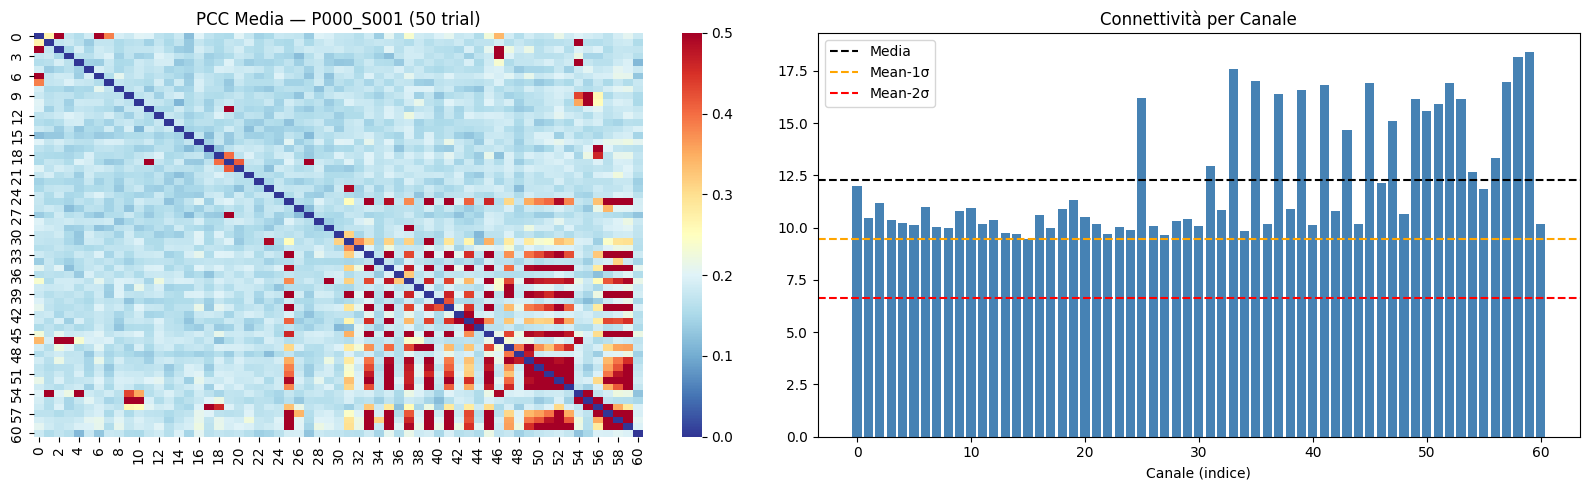


Canali sotto mean-2σ (candidati pruning):


In [6]:
# ============================================================
# ANALISI VISIVA — connettività per canale
# Aiuta a decidere se/cosa prunare
# ============================================================

# Usa primo soggetto come campione
sample_dir = session_dirs[0]
csv_files  = sorted(sample_dir.iterdir())[:50]   # 50 trial campione

print(f"Calcolo PCC media su {len(csv_files)} trial ({sample_dir.name})...")
pcc_sum = np.zeros((N_CHANS, N_CHANS))
for csv_path in tqdm(csv_files):
    x_np = load_csv_trial(csv_path)
    pcc_sum += pcc_matrix(x_np)
pcc_avg = pcc_sum / len(csv_files)

ch_connectivity = pcc_avg.sum(axis=1)
mean_conn = ch_connectivity.mean()
std_conn  = ch_connectivity.std()

# Nomi canali dall'ordine nel CSV (basato su ebneuro.csv se disponibile)
ch_labels = [str(i) for i in range(N_CHANS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pcc_avg, ax=axes[0], cmap="RdYlBu_r", vmin=0, vmax=0.5)
axes[0].set_title(f"PCC Media — {sample_dir.name} ({len(csv_files)} trial)")

colors = ["red" if c < mean_conn - 2*std_conn else "steelblue" for c in ch_connectivity]
axes[1].bar(range(N_CHANS), ch_connectivity, color=colors)
axes[1].axhline(mean_conn, color="black", linestyle="--", label="Media")
axes[1].axhline(mean_conn - std_conn, color="orange", linestyle="--", label="Mean-1σ")
axes[1].axhline(mean_conn - 2*std_conn, color="red", linestyle="--", label="Mean-2σ")
axes[1].set_xlabel("Canale (indice)")
axes[1].set_title("Connettività per Canale")
axes[1].legend()

plt.tight_layout()
fig_path = project_root / "figures" / f"eeg07e_connectivity_{sample_dir.name}.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()

print("\nCanali sotto mean-2σ (candidati pruning):")
for i, conn in enumerate(ch_connectivity):
    if conn < mean_conn - 2*std_conn:
        print(f"  idx={i:2d}  conn={conn:.4f}")

In [7]:
# ============================================================
# PRUNING CANALI
# ============================================================

# Indici attivi (tutti e 61 di default)
active_idx = list(range(N_CHANS))

# Pruning per sigma
if CHANNEL_PRUNING_SIGMA is not None:
    thresh = mean_conn - CHANNEL_PRUNING_SIGMA * std_conn
    active_idx = [i for i in active_idx if ch_connectivity[i] >= thresh]
    print(f"Pruning σ={CHANNEL_PRUNING_SIGMA}: rimasti {len(active_idx)}/{N_CHANS} canali")

# Pruning per nome (richiede mapping idx→nome se disponibile)
if CHANNEL_DROP_NAMES:
    print(f"Drop esplicito: {CHANNEL_DROP_NAMES} — imposta indici in CHANNEL_DROP_NAMES come indici numerici")

N_ACTIVE = len(active_idx)
print(f"Canali attivi: {N_ACTIVE}/{N_CHANS}")

Canali attivi: 61/61


In [8]:
# ============================================================
# FUNZIONE HELPER: itera tutti i trial da CSV
# ============================================================

def iter_all_trials():
    """
    Generator: itera tutte le cartelle PXXX_SYYY e tutti i CSV.
    Yields: (x_np, label_id, cluster_id, subj_id, sess_id)
    Salta file con parola non in label2idx o label_id non in labelid2cluster.
    """
    for sess_dir in sorted(CSV_ROOT.iterdir()):
        if not sess_dir.is_dir():
            continue
        subj_id, sess_id = parse_folder(sess_dir.name)
        for csv_path in sorted(sess_dir.iterdir()):
            if csv_path.suffix != ".csv":
                continue
            word = csv_path.stem.replace("_img", "")
            if word not in word2labelid:
                continue
            label_id = word2labelid[word]
            if label_id not in labelid2cluster:
                continue
            cluster_id = labelid2cluster[label_id]
            x_np = load_csv_trial(csv_path)[active_idx, :]   # (N_ACTIVE, 384)
            yield x_np, label_id, cluster_id, subj_id, sess_id

# Conta trial totali
n_total = sum(1 for _ in iter_all_trials())
print(f"Trial totali validi: {n_total}")
print(f"(atteso ~{len(session_dirs) * 110} = {len(session_dirs)} sess × 110 parole)")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
# ============================================================
# BUILD GRAPH TENSORS (PCC / PLV / wPLI)
# Output: data/interim/graphs/graph_{method}_k{k}.pt
# ============================================================

CONN_FN = {"pcc": pcc_matrix, "plv": plv_matrix, "wpli": wpli_matrix}

for method in METHODS:
    for k in K_VALUES:
        out_path = GRAPHS_DIR / f"graph_{method}_k{k}.pt"
        if out_path.exists() and not FORCE_REBUILD:
            print(f"Skip: {out_path.name}")
            continue

        print(f"\nCostruendo {out_path.name}...")
        conn_fn   = CONN_FN[method]
        data_list = []

        for x_np, label_id, cluster_id, subj_id, sess_id in tqdm(
                iter_all_trials(), total=n_total, desc=f"{method} k={k}"):

            matrix     = conn_fn(x_np)
            edge_index = knn_edge_index(matrix, k=k, threshold=EDGE_THRESHOLD)

            data_list.append(Data(
                x          = torch.tensor(x_np, dtype=torch.float32),
                edge_index = edge_index,
                y          = torch.tensor(cluster_id, dtype=torch.long),
                label_id   = torch.tensor(label_id,   dtype=torch.long),
                subj       = torch.tensor(subj_id,    dtype=torch.long),
                sess       = torch.tensor(sess_id,    dtype=torch.long),
            ))

        torch.save(data_list, out_path)
        print(f"  ✅ Salvato: {out_path.name} — {len(data_list)} grafi  x.shape={data_list[0].x.shape}")

In [ ]:
# ============================================================
# BUILD HYPERGRAPH TENSORS
# Output: data/interim/graphs/hgraph_k{k}.pt
# ============================================================

if BUILD_HGNN:
    for k in [K_HYPER]:
        out_path = GRAPHS_DIR / f"hgraph_k{k}.pt"
        if out_path.exists() and not FORCE_REBUILD:
            print(f"Skip: {out_path.name}")
            continue

        print(f"\nCostruendo {out_path.name}...")
        data_list = []

        for x_np, label_id, cluster_id, subj_id, sess_id in tqdm(
                iter_all_trials(), total=n_total, desc=f"hgraph k={k}"):

            he_index     = hyperedge_index_fn(x_np, k=k, threshold=EDGE_THRESHOLD)
            n_hyperedges = he_index[1].max().item() + 1

            data_list.append(Data(
                x               = torch.tensor(x_np, dtype=torch.float32),
                hyperedge_index = he_index,
                num_hyperedges  = n_hyperedges,
                y               = torch.tensor(cluster_id, dtype=torch.long),
                label_id        = torch.tensor(label_id,   dtype=torch.long),
                subj            = torch.tensor(subj_id,    dtype=torch.long),
                sess            = torch.tensor(sess_id,    dtype=torch.long),
            ))

        torch.save(data_list, out_path)
        print(f"  ✅ Salvato: {out_path.name} — {len(data_list)} ipergrafi")

In [ ]:
# ============================================================
# SANITY CHECK + COMPARISON PLOT GRAFO vs IPERGRAFO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print(f"=== File in {GRAPHS_DIR} ===")
graph_data  = {}
hgraph_data = {}

for pt_file in sorted(GRAPHS_DIR.glob("*.pt")):
    dl = torch.load(pt_file, weights_only=False)
    d0 = dl[0]
    subj_ids = sorted(set(d.subj.item() for d in dl))
    y_vals   = [d.y.item() for d in dl]

    # Distingui grafo da ipergrafo per nome file
    is_hgraph = pt_file.name.startswith("hgraph")

    if not is_hgraph:
        ei = d0.edge_index
        print(f"  {pt_file.name}: {len(dl)} grafi | "
              f"x={d0.x.shape} | edge_index={ei.shape if ei is not None else 'None'} | "
              f"n_subj={len(subj_ids)} | y_range=[{min(y_vals)},{max(y_vals)}]")
        graph_data[pt_file.stem] = dl
    else:
        he = d0.hyperedge_index
        print(f"  {pt_file.name}: {len(dl)} ipergrafi | "
              f"x={d0.x.shape} | he={he.shape if he is not None else 'None'} | "
              f"n_he={d0.num_hyperedges} | y_range=[{min(y_vals)},{max(y_vals)}]")
        hgraph_data[pt_file.stem] = dl

print(f"\n✅ Sanity check OK — {N_ACTIVE}/{N_CHANS} canali, schema={CLUSTER_SCHEME}")


=== File in /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/graphs ===
  graph_pcc_k6.pt: 38883 grafi | x=torch.Size([61, 384]) | edge_index=torch.Size([2, 732]) | n_subj=74 | y_range=[0,3]
  graph_plv_k6.pt: 38883 grafi | x=torch.Size([61, 384]) | edge_index=torch.Size([2, 732]) | n_subj=74 | y_range=[0,3]
  hgraph_k6.pt: 38883 ipergrafi | x=torch.Size([61, 384]) | he=torch.Size([2, 427]) | n_he=61 | y_range=[0,3]

✅ Sanity check OK — 61/61 canali, schema=concr4


In [11]:
%matplotlib inline

import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import networkx as nx
import pandas as pd
from scipy.spatial import ConvexHull

# ---- Posizioni elettrodi ----
_eloc_candidates = [
    project_root / "data" / "interim" / "ebneuro.csv",
    Path("/mnt/c/Users/students/Desktop/Paolo/LM_Thesis/ebneuro.csv"),
]
_eloc_df = None
for _p in _eloc_candidates:
    if _p.exists():
        _eloc_df = pd.read_csv(_p, sep=";", decimal=","); break

def get_positions(n_nodes):
    if _eloc_df is not None and len(_eloc_df) >= n_nodes:
        df = _eloc_df.iloc[:n_nodes]
        theta_rad = np.deg2rad(df["theta"].values.astype(float))
        radius    = df["radius"].values.astype(float)
        return np.stack([radius*np.sin(theta_rad), radius*np.cos(theta_rad)], axis=1)
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    return np.stack([np.cos(angles), np.sin(angles)], axis=1)

def draw_blob(ax, pos, members, color, alpha=0.25):
    pts = pos[members]
    if len(pts) < 3:
        cx, cy = pts.mean(axis=0)
        ax.add_patch(plt.Circle((cx,cy), 0.06, facecolor=color, edgecolor=color, alpha=alpha, zorder=1)); return
    try:
        hull = ConvexHull(pts)
        hpts = pts[hull.vertices]
        ctr  = hpts.mean(axis=0)
        exp  = ctr + (hpts - ctr) * 1.3
        ax.add_patch(plt.Polygon(exp, closed=True, facecolor=color, edgecolor=color,
                                 alpha=alpha, zorder=1, lw=1.5, ))
    except Exception: pass

def plot_comparison(subj, word, session, k, max_he):
    csv_path = CSV_ROOT / f"{subj}_{session}" / f"{word}_img.csv"
    if not csv_path.exists():
        print(f"Non trovato: {csv_path}"); return
    x_np = load_csv_trial(csv_path)
    N    = x_np.shape[0]
    pos  = get_positions(N)
    pcc  = np.abs(np.corrcoef(x_np)); np.fill_diagonal(pcc, 0.0)
    ei   = knn_edge_index(pcc, k=k).numpy()
    he   = hyperedge_index_fn(x_np, k=k).numpy()
    G    = nx.Graph(); G.add_nodes_from(range(N))
    for s, t in zip(ei[0], ei[1]):
        if s < t: G.add_edge(int(s), int(t))
    node_deg = np.array([G.degree(i) for i in range(N)], dtype=float)
    he_members = {}
    for v, e in zip(he[0], he[1]): he_members.setdefault(int(e),[]).append(int(v))
    n_he_per_node = np.bincount(he[0], minlength=N)
    n_he = int(he[1].max()) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"{subj}  |  '{word}'  |  {session}  |  k={k}", fontsize=13, fontweight="bold")

    ax1.set_title(f"Grafo k-NN  —  {G.number_of_edges()} archi")
    ew = [pcc[u,v] for u,v in G.edges()]
    nx.draw_networkx_edges(G, pos={i:pos[i] for i in range(N)}, ax=ax1,
                           edge_color=ew, edge_cmap=cm.Blues, width=1.5, alpha=0.7)
    sc1 = ax1.scatter(pos[:,0], pos[:,1], s=60+node_deg*20, c=node_deg,
                      cmap="plasma", zorder=5, edgecolors="black", lw=0.6)
    plt.colorbar(sc1, ax=ax1, label="Grado nodo")
    ax1.add_patch(plt.Circle((0,0),0.62,fill=False,color="gray",ls="--",lw=1.5))
    ax1.set_aspect("equal"); ax1.axis("off")

    ax2.set_title(f"Ipergrafo  —  {n_he} iperedge (prime {min(max_he,n_he)})")
    colors = cm.tab20(np.linspace(0,1,min(max_he,n_he)))
    for (e_id, members), color in zip(list(he_members.items())[:max_he], colors):
        draw_blob(ax2, pos, members, color=color[:3])
    sc2 = ax2.scatter(pos[:,0], pos[:,1], s=60+n_he_per_node*5, c=n_he_per_node,
                      cmap="YlOrRd", zorder=5, edgecolors="black", lw=0.6)
    plt.colorbar(sc2, ax=ax2, label="N° iperedge per nodo")
    ax2.add_patch(plt.Circle((0,0),0.62,fill=False,color="gray",ls="--",lw=1.5))
    ax2.set_aspect("equal"); ax2.axis("off")
    plt.tight_layout(); plt.show()

# ---- Widget (istanze uniche, usate sia nei controlli che nella funzione) ----
_subjects = sorted(set(d.name.split("_")[0] for d in CSV_ROOT.iterdir() if d.is_dir()))
_words    = sorted(word2labelid.keys())
_sessions = sorted(set(d.name.split("_")[1] for d in CSV_ROOT.iterdir() if d.is_dir()))

w_subj = widgets.Dropdown(options=_subjects, value=_subjects[0], description="Soggetto:")
w_word = widgets.Dropdown(options=_words,    value=_words[0],    description="Parola:")
w_sess = widgets.Dropdown(options=_sessions, value=_sessions[0], description="Sessione:")
w_k    = widgets.IntSlider(min=2, max=15, value=6,  description="k:")
w_he   = widgets.IntSlider(min=5, max=61, value=20, description="Max he:")

out = interactive_output(plot_comparison,
    {"subj": w_subj, "word": w_word, "session": w_sess, "k": w_k, "max_he": w_he})

display(VBox([HBox([w_subj, w_word, w_sess]), HBox([w_k, w_he]), out]))

Calcolo ['pcc'] su campione (5 sogg × 2 sess × 20 parole)...


/tmp/ipykernel_61554/276950953.py:80: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61554/276950953.py:80: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61554/276950953.py:81: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(project_root/"figures"/"eeg07e_connectivity_analysis.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_61554/276950953.py:81: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(project_root/"figures"/"eeg07e_connectivity_analysis.png", dpi=120, bbox_inches="tight")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/daniele_u/miniconda3/envs/

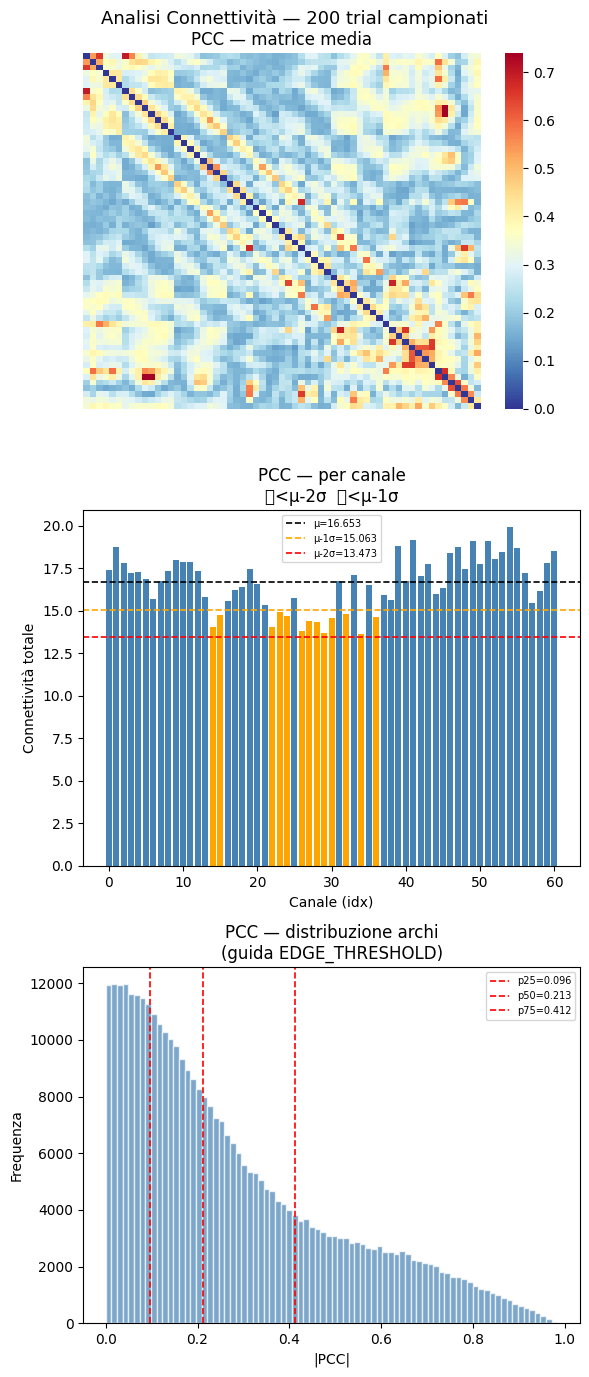


=============================================  PCC
  Canali deboli (< μ-2σ = 13.473):
    idx = []  → aggiungi a CHANNEL_DROP_NAMES
  EDGE_THRESHOLD consigliato:
    p25 = 0.096  →  mantiene 75% archi
    p50 = 0.213  →  mantiene 50% archi
    p75 = 0.412  →  mantiene 25% archi


In [15]:
# ============================================================
# ANALISI CONNETTIVITÀ — basata su METHODS definiti in cella 1
# Confronto PCC vs PLV vs wPLI + guida pruning
# ============================================================

N_SAMPLE_SUBJ = 5
N_SAMPLE_SESS = 2
WORD_SAMPLE   = _words[:20]

CONN_FN = {"pcc": pcc_matrix, "plv": plv_matrix, "wpli": wpli_matrix}

# Raccogli dati per ogni metodo in METHODS
results = {m: {"sum": np.zeros((N_CHANS, N_CHANS)), "vals": [], "n": 0}
           for m in METHODS}

print(f"Calcolo {METHODS} su campione ({N_SAMPLE_SUBJ} sogg × {N_SAMPLE_SESS} sess × {len(WORD_SAMPLE)} parole)...")

for subj in _subjects[:N_SAMPLE_SUBJ]:
    for sess in _sessions[:N_SAMPLE_SESS]:
        for word in WORD_SAMPLE:
            csv_path = CSV_ROOT / f"{subj}_{sess}" / f"{word}_img.csv"
            if not csv_path.exists(): continue
            x_np = load_csv_trial(csv_path)
            for m in METHODS:
                mat = CONN_FN[m](x_np)
                results[m]["sum"] += mat
                results[m]["vals"].extend(mat[np.triu_indices(N_CHANS, k=1)].tolist())
                results[m]["n"]   += 1

for m in METHODS:
    results[m]["avg"]  = results[m]["sum"] / results[m]["n"]
    results[m]["vals"] = np.array(results[m]["vals"])
    results[m]["conn"] = results[m]["avg"].sum(axis=1)

n_methods = len(METHODS)
fig, axes  = plt.subplots(3, n_methods, figsize=(6*n_methods, 14))
if n_methods == 1: axes = axes[:, np.newaxis]
fig.suptitle(f"Analisi Connettività — {results[METHODS[0]]['n']} trial campionati", fontsize=13)

for col, m in enumerate(METHODS):
    avg   = results[m]["avg"]
    conn  = results[m]["conn"]
    vals  = results[m]["vals"]
    mean_c, std_c = conn.mean(), conn.std()

    # riga 0: heatmap
    import seaborn as sns
    sns.heatmap(avg, ax=axes[0, col], cmap="RdYlBu_r",
                vmin=0, vmax=np.percentile(vals, 95),
                xticklabels=False, yticklabels=False)
    axes[0, col].set_title(f"{m.upper()} — matrice media")

    # riga 1: connettività per canale
    colors = ["red"    if c < mean_c - 2*std_c else
              "orange" if c < mean_c -   std_c else
              "steelblue" for c in conn]
    axes[1, col].bar(range(N_CHANS), conn, color=colors)
    axes[1, col].axhline(mean_c,           color="black",  ls="--", lw=1.2,
                         label=f"μ={mean_c:.3f}")
    axes[1, col].axhline(mean_c -   std_c, color="orange", ls="--", lw=1.2,
                         label=f"μ-1σ={mean_c-std_c:.3f}")
    axes[1, col].axhline(mean_c - 2*std_c, color="red",    ls="--", lw=1.2,
                         label=f"μ-2σ={mean_c-2*std_c:.3f}")
    axes[1, col].set_xlabel("Canale (idx)")
    axes[1, col].set_ylabel("Connettività totale")
    axes[1, col].set_title(f"{m.upper()} — per canale\n🔴<μ-2σ  🟠<μ-1σ")
    axes[1, col].legend(fontsize=7)

    # riga 2: distribuzione pesi (guida EDGE_THRESHOLD)
    axes[2, col].hist(vals, bins=80, color="steelblue", alpha=0.7, edgecolor="white")
    thresholds = np.percentile(vals, [25, 50, 75])
    for thr, pct in zip(thresholds, [25, 50, 75]):
        axes[2, col].axvline(thr, color="red", ls="--", lw=1.2,
                             label=f"p{pct}={thr:.3f}")
    axes[2, col].set_xlabel(f"|{m.upper()}|")
    axes[2, col].set_ylabel("Frequenza")
    axes[2, col].set_title(f"{m.upper()} — distribuzione archi\n(guida EDGE_THRESHOLD)")
    axes[2, col].legend(fontsize=7)

plt.tight_layout()
plt.savefig(project_root/"figures"/"eeg07e_connectivity_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Riepilogo testuale ----
for m in METHODS:
    conn   = results[m]["conn"]
    vals   = results[m]["vals"]
    mean_c = conn.mean(); std_c = conn.std()
    print(f"\n{'='*45}  {m.upper()}")
    print(f"  Canali deboli (< μ-2σ = {mean_c-2*std_c:.3f}):")
    weak = np.where(conn < mean_c - 2*std_c)[0]
    print(f"    idx = {weak.tolist()}  → aggiungi a CHANNEL_DROP_NAMES")
    print(f"  EDGE_THRESHOLD consigliato:")
    for pct in [25, 50, 75]:
        thr  = np.percentile(vals, pct)
        kept = (vals >= thr).mean()*100
        print(f"    p{pct} = {thr:.3f}  →  mantiene {kept:.0f}% archi")

In [ ]:
# ============================================================
# PRUNING + SALVATAGGIO TENSORI PRUNATI
# Input:  data/interim/graphs/graph_{method}_k{k}.pt
# Output: data/interim/graphs/graph_{method}_k{k}_thr{t}.pt
# ============================================================

# ---- Parametri pruning (decidi dopo analisi) ----
# ---- Parametri pruning: presi dall'analisi sopra ----
PRUNE_EDGE_THRESHOLD = float(np.percentile(
    results[METHODS[0]]["vals"], 50))   # p50 di default — cambia 50 con 25/75
PRUNE_CHANNELS       = list(np.where(
    results[METHODS[0]]["conn"] < results[METHODS[0]]["conn"].mean()
    - 2 * results[METHODS[0]]["conn"].std())[0])

print(f"PRUNE_EDGE_THRESHOLD = {PRUNE_EDGE_THRESHOLD:.3f}")
print(f"PRUNE_CHANNELS       = {PRUNE_CHANNELS} ({'nessuno' if not PRUNE_CHANNELS else len(PRUNE_CHANNELS)+' canali'})")

# ---- Applica pruning ai tensori già costruiti ----
pt_files = sorted(GRAPHS_DIR.glob("graph_*.pt")) + \
           sorted(GRAPHS_DIR.glob("hgraph_*.pt"))

for pt_file in pt_files:
    # Salta file già prunati
    if "thr" in pt_file.name: continue

    suffix   = f"_thr{str(PRUNE_EDGE_THRESHOLD).replace('.','')}"
    out_path = pt_file.with_name(pt_file.stem + suffix + ".pt")

    if out_path.exists() and not FORCE_REBUILD:
        print(f"Skip: {out_path.name}"); continue

    print(f"Pruning {pt_file.name} → {out_path.name}...")
    data_list    = torch.load(pt_file, weights_only=False)
    pruned_list  = []
    is_hgraph    = pt_file.name.startswith("hgraph")

    for d in tqdm(data_list, desc=pt_file.stem):
        x = d.x.numpy()   # (N, T)

        # ---- Pruning canali ----
        if PRUNE_CHANNELS:
            keep = [i for i in range(x.shape[0]) if i not in PRUNE_CHANNELS]
            x    = x[keep, :]

        x_t = torch.tensor(x, dtype=torch.float32)

        if not is_hgraph:
            # ---- Pruning edge: ricostruisce edge_index con soglia ----
            pcc        = pcc_matrix(x)
            edge_index = knn_edge_index(pcc, k=K_VALUES[0],
                                        threshold=PRUNE_EDGE_THRESHOLD)
            pruned_list.append(Data(
                x          = x_t,
                edge_index = edge_index,
                y          = d.y,
                label_id   = d.label_id,
                subj       = d.subj,
                sess       = d.sess,
            ))
        else:
            # ---- Pruning iperedge: ricostruisce con soglia ----
            he_index     = hyperedge_index_fn(x, k=K_HYPER,
                                              threshold=PRUNE_EDGE_THRESHOLD)
            n_hyperedges = he_index[1].max().item() + 1
            pruned_list.append(Data(
                x               = x_t,
                hyperedge_index = he_index,
                num_hyperedges  = n_hyperedges,
                y               = d.y,
                label_id        = d.label_id,
                subj            = d.subj,
                sess            = d.sess,
            ))

    torch.save(pruned_list, out_path)
    orig_edges = data_list[0].edge_index.shape[1] if not is_hgraph else 0
    new_edges  = pruned_list[0].edge_index.shape[1] if not is_hgraph else 0
    print(f"  ✅ {out_path.name} — {len(pruned_list)} oggetti"
          + (f" | archi: {orig_edges}→{new_edges} ({new_edges/orig_edges*100:.0f}%)" if not is_hgraph else ""))

print("\nFile in GRAPHS_DIR:")
for f in sorted(GRAPHS_DIR.glob("*.pt")):
    mb = f.stat().st_size / 1e6
    print(f"  {f.name:<45} {mb:.1f} MB")